# Configuration


In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv(".pacing.env", override=True)  # Change to ".env.simulation" for simulation data

# Load configuration from .env
simulation_root = os.getenv("SIMULATION_DIR")
converted_dir = os.getenv("CONVERT_TARGET_DIR")
unfiltered_base_dir = os.getenv("UNFILTERED_BASE_DIR")
comparison_checkpoint_dir = os.getenv("COMPARISON_CHECKPOINT_DIR")
comparison_output_dir = os.getenv("COMPARISON_OUTPUT_DIR")
sim_targets_dir = os.getenv("SIM_TARGETS_DIR")
sim_constraints_dir = os.getenv("SIM_CONSTRAINTS_DIR")
filtered_pacing_segments_dir = os.getenv("FILTERED_PACING_SEG_DIR")

# Display loaded configuration
print("Configuration loaded from .env:")
print(f"  SIMULATION_DIR: {simulation_root}")
print(f"  CONVERT_TARGET_DIR: {converted_dir}")
print(f"  UNFILTERED_BASE_DIR: {unfiltered_base_dir}")
print(f"  COMPARISON_CHECKPOINT_DIR: {comparison_checkpoint_dir}")
print(f"  COMPARISON_OUTPUT_DIR: {comparison_output_dir}")
print(f"  SIM_TARGETS_DIR: {sim_targets_dir}")
print(f"  SIM_CONSTRAINTS_DIR: {sim_constraints_dir}")
print(f"  FILTERED_PACING_SEG_DIR: {filtered_pacing_segments_dir}")

# Create directories if they don't exist
os.makedirs(converted_dir, exist_ok=True)
os.makedirs(comparison_checkpoint_dir, exist_ok=True)
os.makedirs(comparison_output_dir, exist_ok=True)

from compile.generator import batch_process_pacing, load_bot_pacing_factors
import polars as pl

bot_pairs = [
    ("MCTS", "Bot_MCTS"),
    ("NN", "Bot_NN"),
    # ("Bot_MLP", "Bot_ML_Classification"),
]

pacing_config_filter = {
    "Timer": [30],
    "ActInterval": [0.1],
    "Round": ["BestOf3"],
    "SkillLeft": ["Boost"],
    "SkillRight": ["Boost"],
}

pacing_factor_bin_size = 1

Configuration loaded from .env:
  SIMULATION_DIR: /Users/defdef/Library/Application Support/DefaultCompany/Sumobot/Logs/Batch/20260811_205027_batch
  CONVERT_TARGET_DIR: .analytic-cache/converted/pacing_fix3
  UNFILTERED_BASE_DIR: local_setup/simulated-13agents
  COMPARISON_CHECKPOINT_DIR: .analytic-cache/batched/filtered_vs_unfiltered
  COMPARISON_OUTPUT_DIR: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts
  SIM_TARGETS_DIR: /Users/defdef/Development/research/sumobot/sumobot/Assets/Resources/Pacing/Sim_Targets/Experiments
  SIM_CONSTRAINTS_DIR: /Users/defdef/Development/research/sumobot/sumobot/Assets/Resources/Pacing/Sim_Constraints
  FILTERED_PACING_SEG_DIR: .analytic-cache/batched/sim_pacing/pacing_segments
Using CPU (GPU not available)


# Compile Data

## Convert Simulation Log to Parquet / CSV

In [2]:
from compile.log_to_parquet import ( 
    convert_all_configs
)

convert_all_configs(simulation_root, converted_dir)

## Batch Pacing Segment

In [ ]:
from compile.generator import batch_process_pacing_segments
import os
import time

# filtered_pacing_segments_dir (FILTERED_PACING_SEG_DIR in .pacing.env) is
# checkpoint_dir/name/pacing_segments - derive both back out so this writes to
# the same place load_filtered_target_tracking below reads from.
pacing_segments_checkpoint_dir = os.path.dirname(os.path.dirname(filtered_pacing_segments_dir))
pacing_segments_name = os.path.basename(os.path.dirname(filtered_pacing_segments_dir))

start = time.time()

batch_process_pacing_segments(
    converted_dir,
    batch_size=4,
    checkpoint_dir=pacing_segments_checkpoint_dir,
    name=pacing_segments_name,
    applied_bots=[b for b, _ in bot_pairs],
    config_filter=pacing_config_filter,
    min_pacing=0,
    max_pacing=1,
)

elapsed_seconds = time.time() - start
hours, remainder = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(remainder, 60)
processing_time = f"{int(hours):02d}:{int(minutes):02d}:{seconds:.2f}"
print(f"\nProcessing Time: {processing_time}")


# Filtered vs Unfiltered Pacing Comparison

Compares MCTS/NN's raw pacing factors (`CollisionRatio`, `AbilityRatio`, `Angle`, `SafeDistance`, `ActionIntensity`, `ActionDensity`, `BotsDistance`, `Velocity` — recomputed offline from `Action`/`Collision` event rows via `compile.generator.batch_process_pacing`, the same formula on both sides) between:

- **Filtered**: MCTS/NN with the dynamic pacing filter applied (`.analytic-cache/converted/pacing_fix3`)
- **Unfiltered**: MCTS/NN's natural behavior with no filter running (`local_setup/simulated-13agents`, 13-agent roster)

Both restricted to the same config: `Timer=30, ActInterval=0.1, Round=BestOf3, SkillLeft=Boost, SkillRight=Boost`.

Note this is a *different* metric family than the Actual-vs-Target charts above — those read `PacingSegment` rows the runtime only logs while the filter is actively steering a match, which the unfiltered runs never produce (verified: `local_setup/simulated-13agents` parquet files only ever contain `Category in {"Action", "Collision"}`).


## Prepare Data

In [2]:
for filtered_bot, unfiltered_bot in bot_pairs:
    batch_process_pacing(
        converted_dir,
        batch_size=10,
        checkpoint_dir=comparison_checkpoint_dir,
        time_bin_size={pacing_factor_bin_size: None},  # raw factors - both sides use the same formula, no cross-run rescale needed
        bot_option=filtered_bot,
        input_format="auto",
        config_filter=pacing_config_filter,
        name=f"filtered_{filtered_bot}",
    )
    batch_process_pacing(
        converted_dir,
        batch_size=10,
        checkpoint_dir=comparison_checkpoint_dir,
        time_bin_size={pacing_factor_bin_size: None},
        bot_option=unfiltered_bot,
        input_format="auto",
        config_filter=pacing_config_filter,
        name=f"unfiltered_{unfiltered_bot}",
    )

from compile.generator import load_filtered_target_tracking

df_target_tracking = load_filtered_target_tracking(
    filtered_pacing_segments_dir,
    bots=[b for b, _ in bot_pairs],
    config_filter=pacing_config_filter,
)


Found 40 CSV/Parquet files to process for bot 'MCTS'

Processing with time_bin_size = 1s (raw)
Skipping pacing batch 1/4 (already processed)
Skipping pacing batch 2/4 (already processed)
Skipping pacing batch 3/4 (already processed)
Skipping pacing batch 4/4 (already processed)
Found 0 CSV/Parquet files to process for bot 'Bot_MCTS'

Processing with time_bin_size = 1s (raw)
Found 40 CSV/Parquet files to process for bot 'NN'

Processing with time_bin_size = 1s (raw)
Skipping pacing batch 1/4 (already processed)
Skipping pacing batch 2/4 (already processed)
Skipping pacing batch 3/4 (already processed)
Skipping pacing batch 4/4 (already processed)
Found 0 CSV/Parquet files to process for bot 'Bot_NN'

Processing with time_bin_size = 1s (raw)


In [3]:
frames = []
for filtered_bot, unfiltered_bot in bot_pairs:
    filtered_df = load_bot_pacing_factors(
        comparison_checkpoint_dir, f"filtered_{filtered_bot}", filtered_bot,
        time_bin_size=pacing_factor_bin_size, group_label="Filtered", canonical_bot=filtered_bot,
    )
    if filtered_df is not None:
        frames.append(filtered_df)

    unfiltered_df = load_bot_pacing_factors(
        comparison_checkpoint_dir, f"unfiltered_{unfiltered_bot}", unfiltered_bot,
        time_bin_size=pacing_factor_bin_size, group_label="Unfiltered", canonical_bot=filtered_bot,
    )
    if unfiltered_df is not None:
        frames.append(unfiltered_df)

df_pacing_factor_comparison = pl.concat(frames, how="diagonal_relaxed") if frames else None
df_pacing_factor_comparison


GameIndex,RoundIndex,Timer,ActInterval,Round,SkillLeft,SkillRight,TimeBin,OpponentBot,CollisionRatio,AbilityRatio,Angle,SafeDistance,ActionIntensity,ActionDensity,BotsDistance,Velocity,Bot,Group
i64,i64,f64,f64,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",1.0,"""FSM""",0.0,0.0,1.0,0.356988,8.440947,-1.4427e-10,0.421422,3.150904,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",2.0,"""FSM""",NaN,0.0,0.0,0.4137,0.508355,-1.4427e-10,0.362396,0.110529,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",3.0,"""FSM""",1.0,0.333333,0.475784,0.417906,10.451684,0.892313,0.33087,0.538741,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",4.0,"""FSM""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",5.0,"""FSM""",NaN,0.0,0.968099,0.437369,7.153344,0.936264,0.255548,0.007164,"""MCTS""","""Filtered"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
48,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",12.0,"""Bot_DQN""",0.0,0.4,0.991409,0.223052,14.196463,1.637134,0.157224,7.2,"""NN""","""Unfiltered"""
49,1,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",1.0,"""Bot_DQN""",NaN,0.0,1.0,0.593485,9.354181,-1.4427e-10,0.506781,3.167277,"""NN""","""Unfiltered"""
49,1,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",2.0,"""Bot_DQN""",1.0,0.25,0.986689,0.843983,8.526821,1.322111,0.253233,2.694705,"""NN""","""Unfiltered"""


## Pacing Factor Breakdown

✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_filtered_vs_unfiltered.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_filtered_vs_unfiltered.png


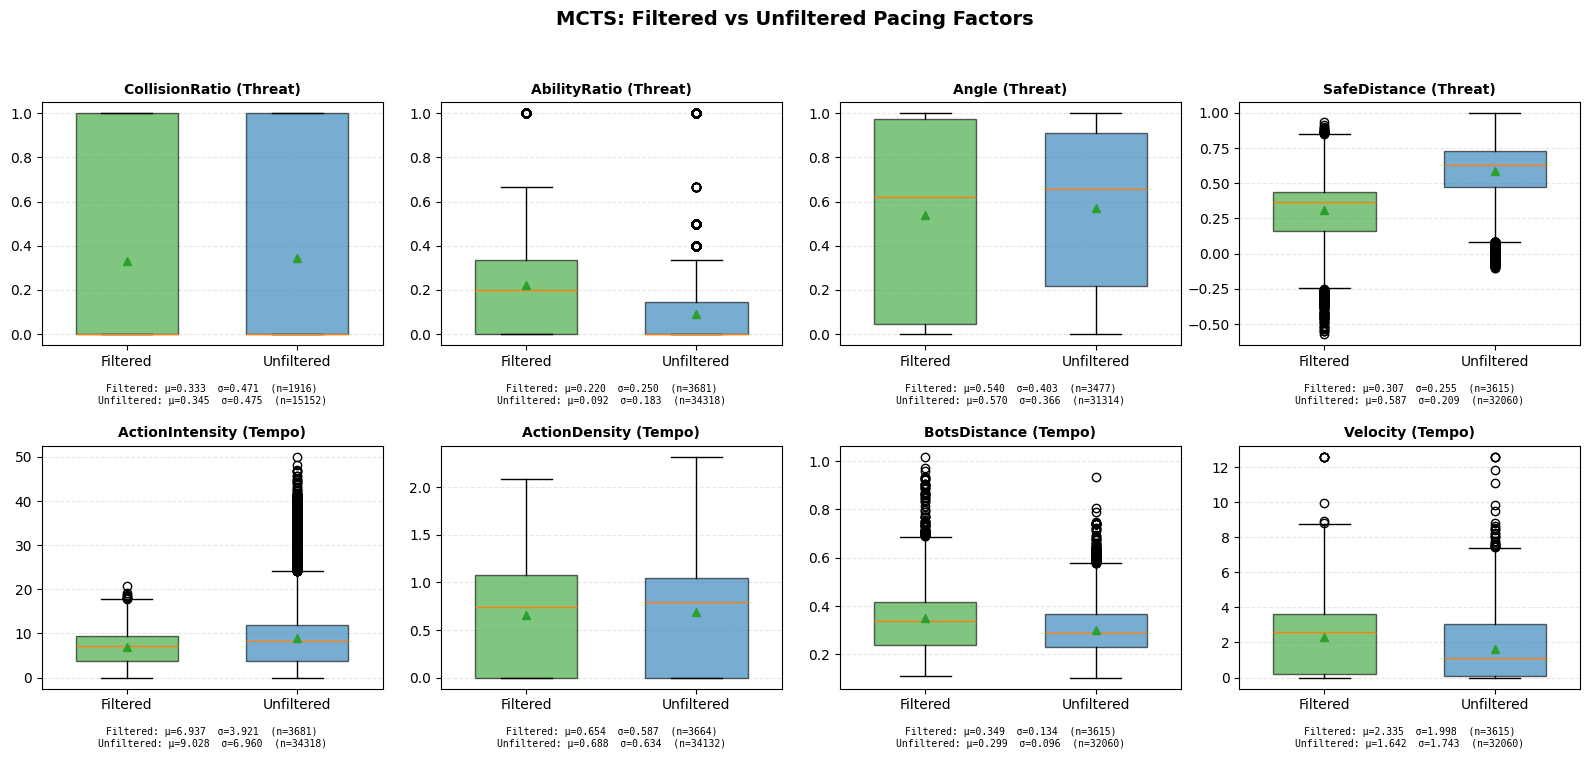

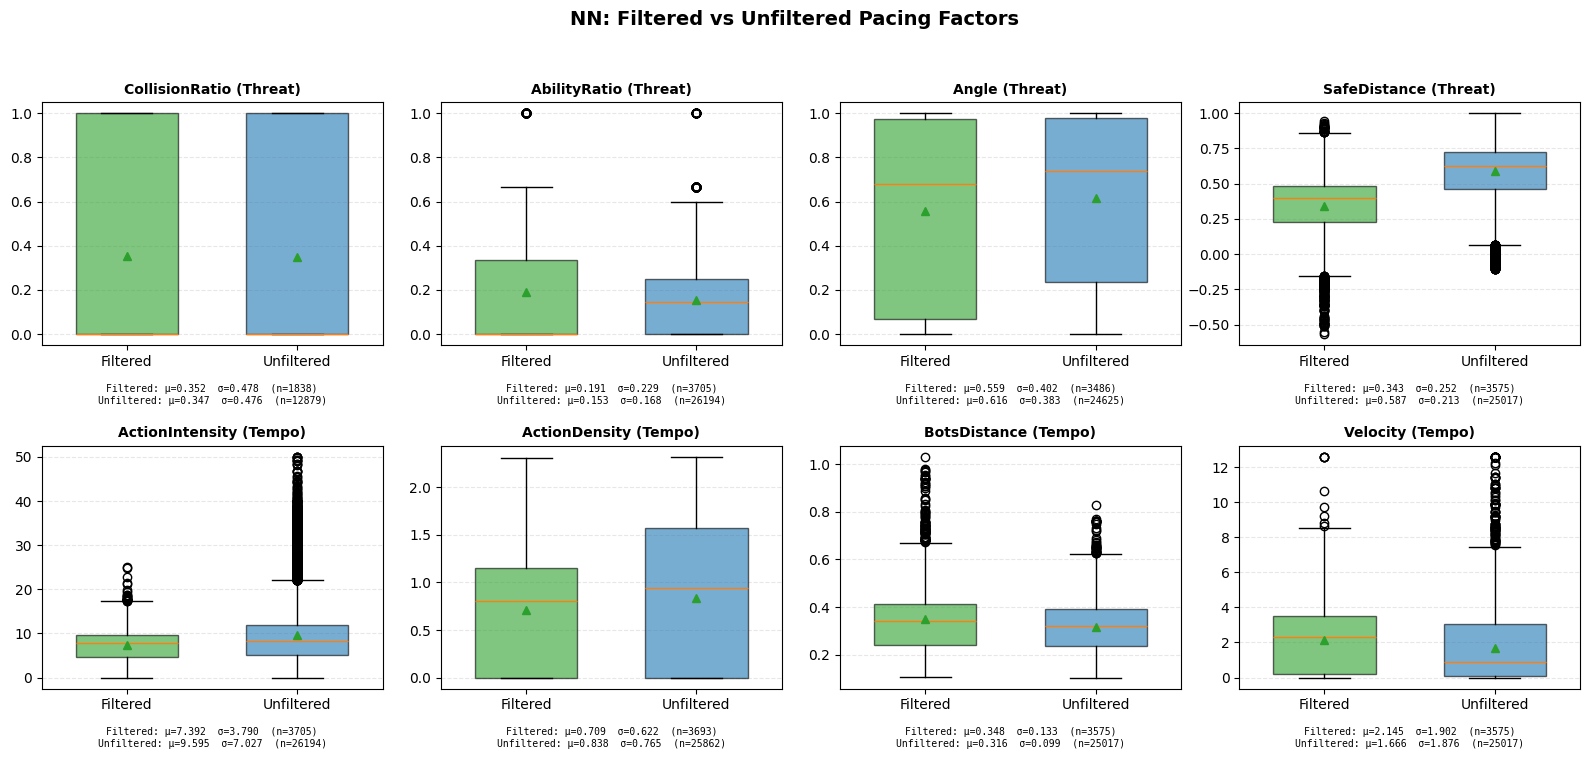

In [23]:
from plotting.pacing_filter_comparison import plot_all_pacing_factor_comparisons

figs_factor_comparison = plot_all_pacing_factor_comparisons(
    df_pacing_factor_comparison, output_dir=comparison_output_dir,
)


## Pacing Over Time (per 1s Segment)

Same data as above, but broken out by `TimeBin` instead of pooled — one point per 1-second segment across the match (30 segments for `Timer=30`), so divergence *when* in the match it happens is visible, not just the aggregate shift.


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_filtered_vs_unfiltered_timeseries.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_filtered_vs_unfiltered_timeseries.png


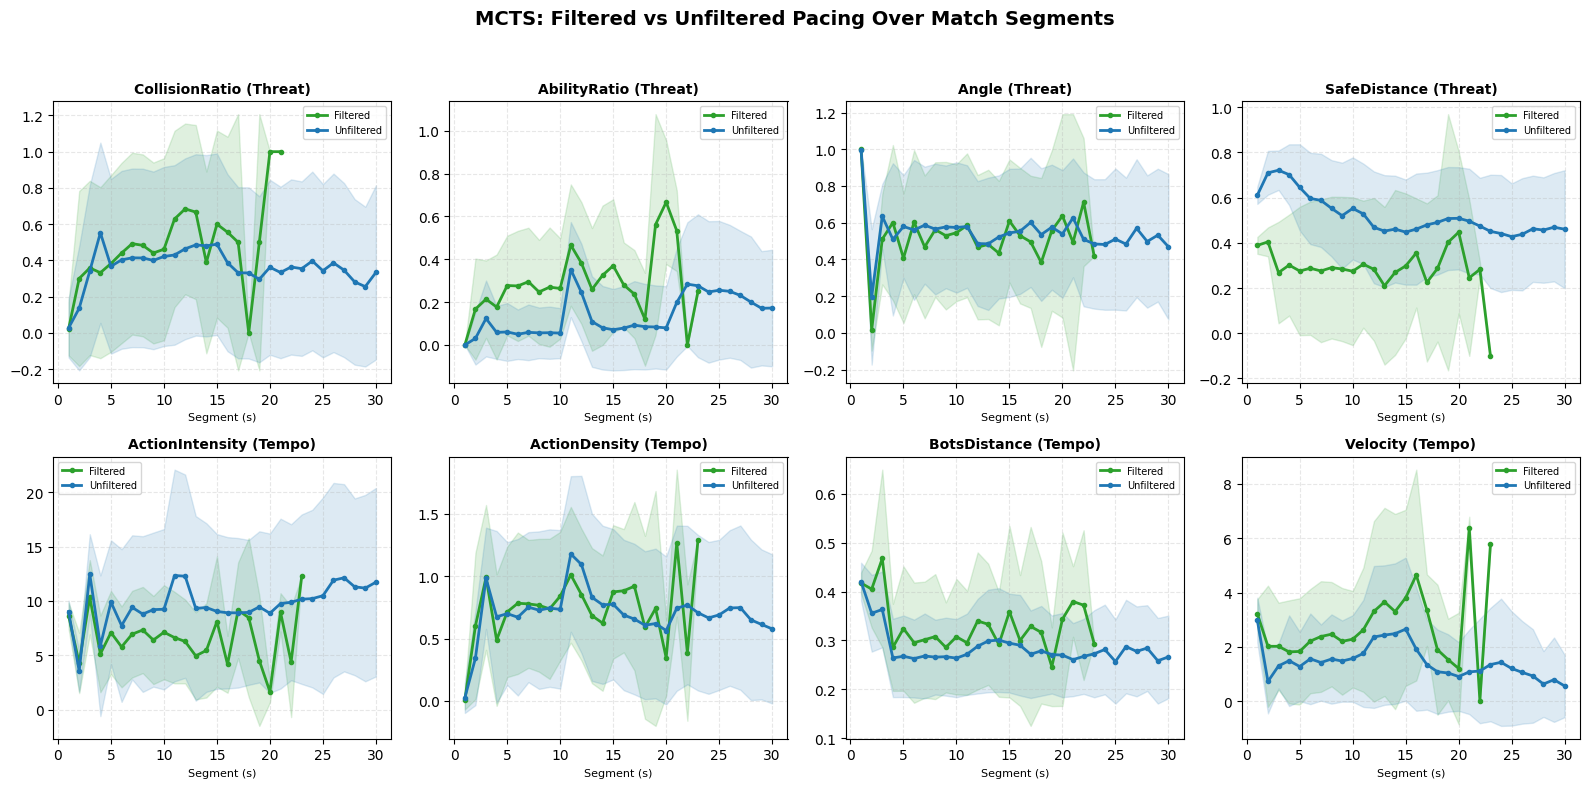

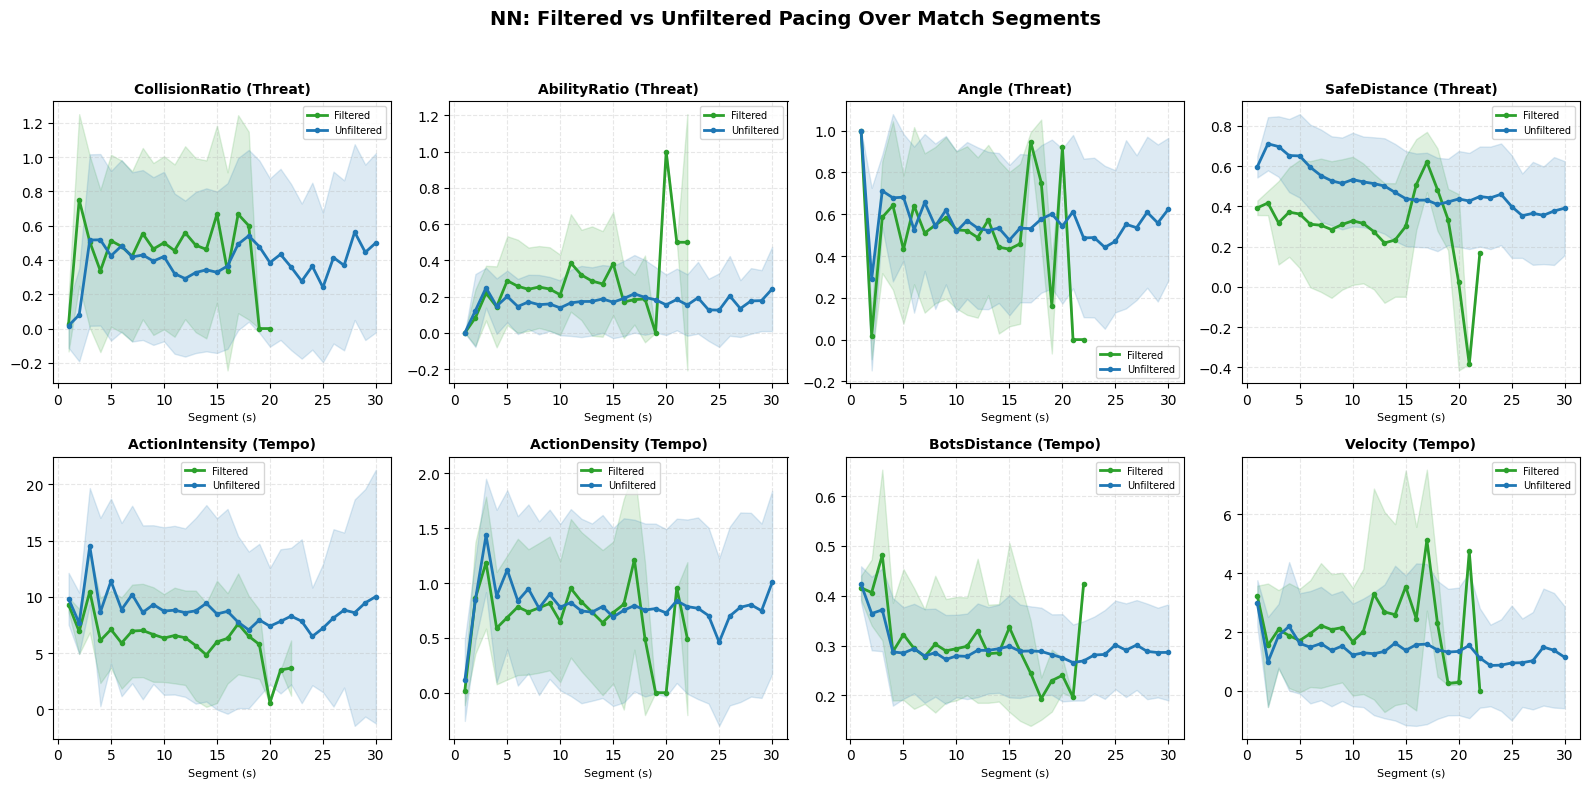

In [32]:
from plotting.pacing_filter_comparison import plot_all_pacing_factor_timeseries

figs_factor_timeseries = plot_all_pacing_factor_timeseries(
    df_pacing_factor_comparison, output_dir=comparison_output_dir,
)


## Overall Pacing (Merged Threat/Tempo Composite)

Merges the 8 raw factors above into a single **Threat**, **Tempo**, and **OverallPacing** score per row — min-max normalized so all 8 factors are on the same [0, 1] scale, then averaged per the engine's own Threat/Tempo grouping (Threat = CollisionRatio/AbilityRatio/Angle/SafeDistance, Tempo = ActionIntensity/ActionDensity/BotsDistance/Velocity, Overall = mean of the two).

**Caveat**: this is an equal-weight approximation, not the engine's real internal formula — those weights aren't available offline, only the 8 raw factors themselves. Useful for a condensed at-a-glance comparison, but don't read exact values as the "true" pacing score the way `ActualOverallPacingScaled` is for the filtered-only Actual-vs-Target charts above.


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_filtered_vs_unfiltered_overall.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_filtered_vs_unfiltered_overall.png


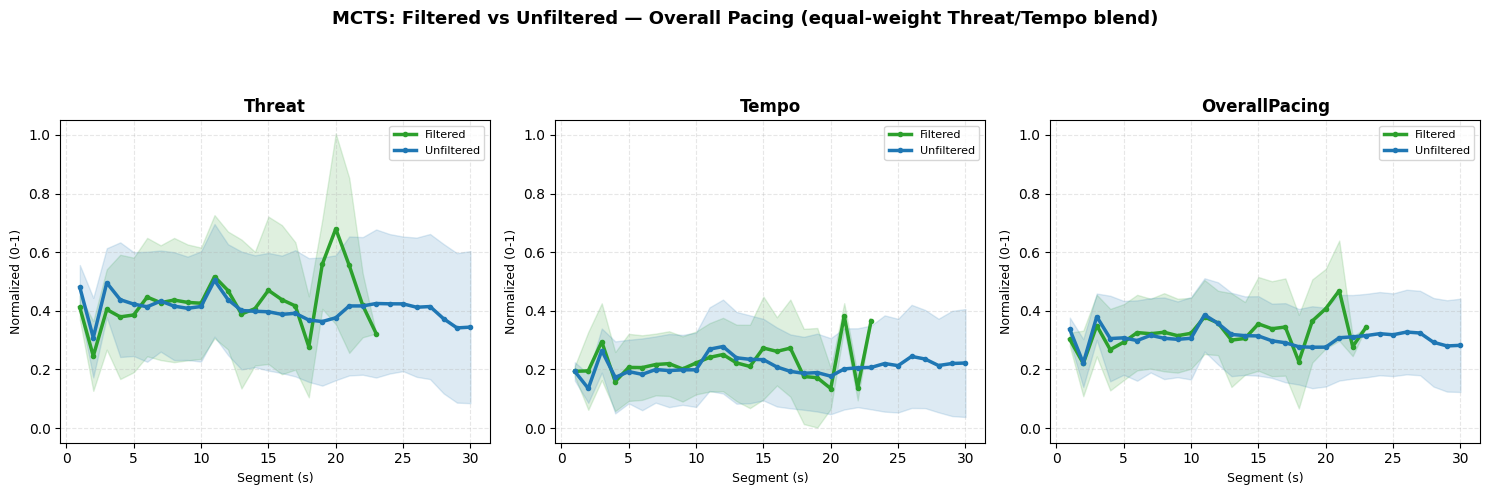

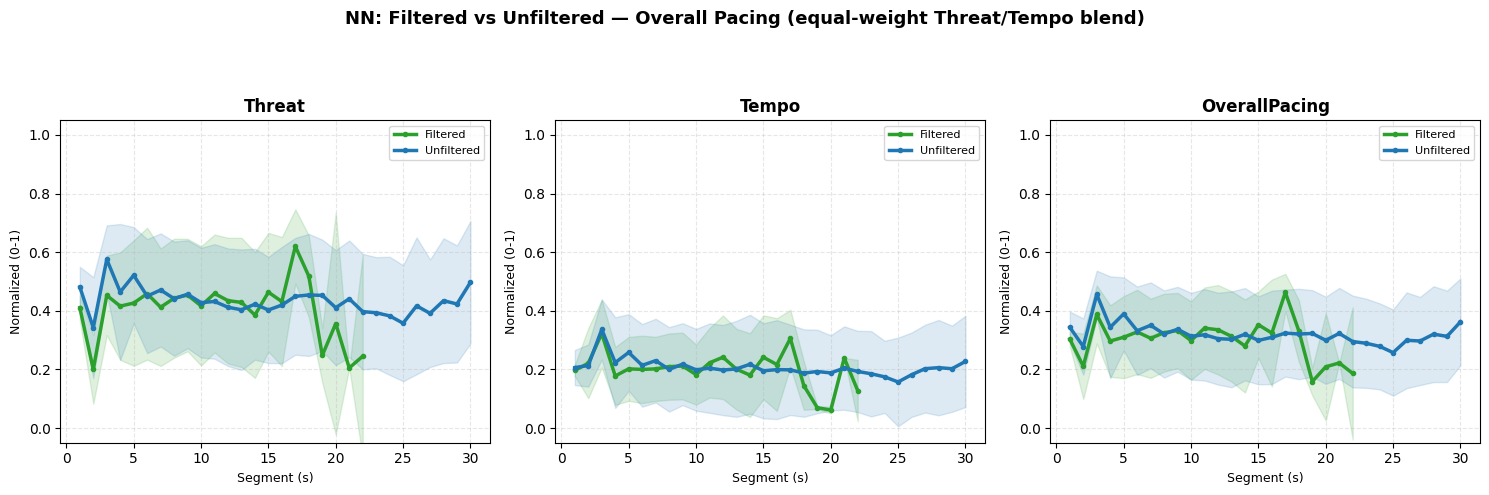

In [33]:
from plotting.pacing_filter_comparison import plot_all_overall_pacing_timeseries

figs_overall_pacing = plot_all_overall_pacing_timeseries(
    df_pacing_factor_comparison, output_dir=comparison_output_dir,
)


## Filtered Actual vs Target (Engine Ground Truth)

`pacing_fix3`'s `PacingSegment` rows already carry the engine's own computed `Tempo`/`Threat`/`OverallPacing` and `Target*` curves — this swaps the Filtered side from the equal-weight offline approximation above to that ground truth, and overlays the predefined Target curve it was steering towards.

One figure per (Bot, PacingTarget) — there are 5 target curve shapes (`default_target_low/med/high`, `linear_increase`, `linear_decrease`); averaging them together would cancel out the shape, so each gets its own chart. `LocalSegmentIndex` isn't a fixed 1s bin (segment count varies with how long a round ran), so it's converted to elapsed seconds via `RoundDuration / NumSegmentsInRound` to land on the same "Segment (s)" axis as the charts above.

Each panel shows: **Target** (predefined curve), **Filtered Actual** (mean ± std band across matching rounds, plus a linear trend line), **MSE(Actual, Target)** annotated, and the **Unfiltered** offline-approximated line from before as light context (different scale/formula — not a strict apples-to-apples number, directional only).


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_default_target_high_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_default_target_low_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_default_target_med_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_linear_decrease_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_linear_increase_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_default_target_high_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_default_target_low_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_default_target_med_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfilt

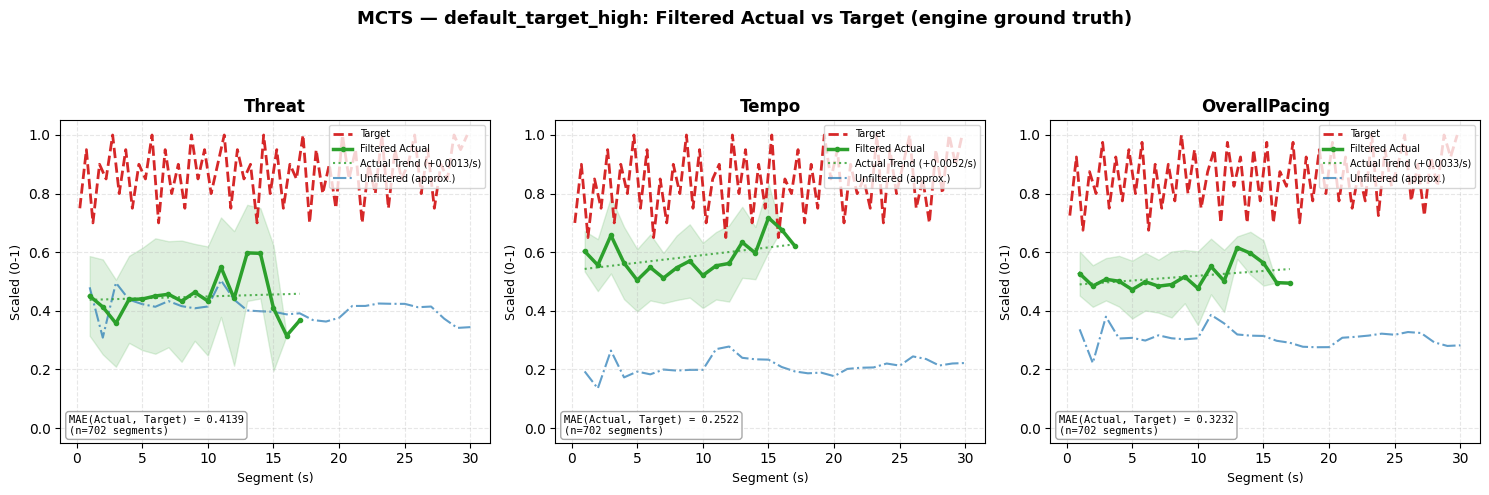

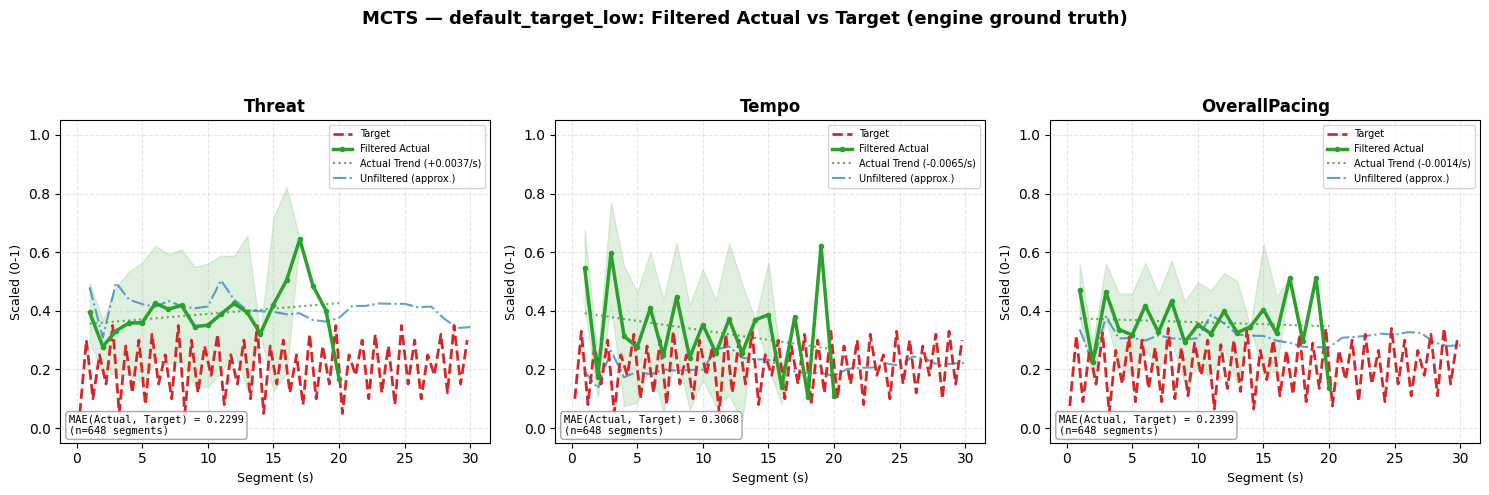

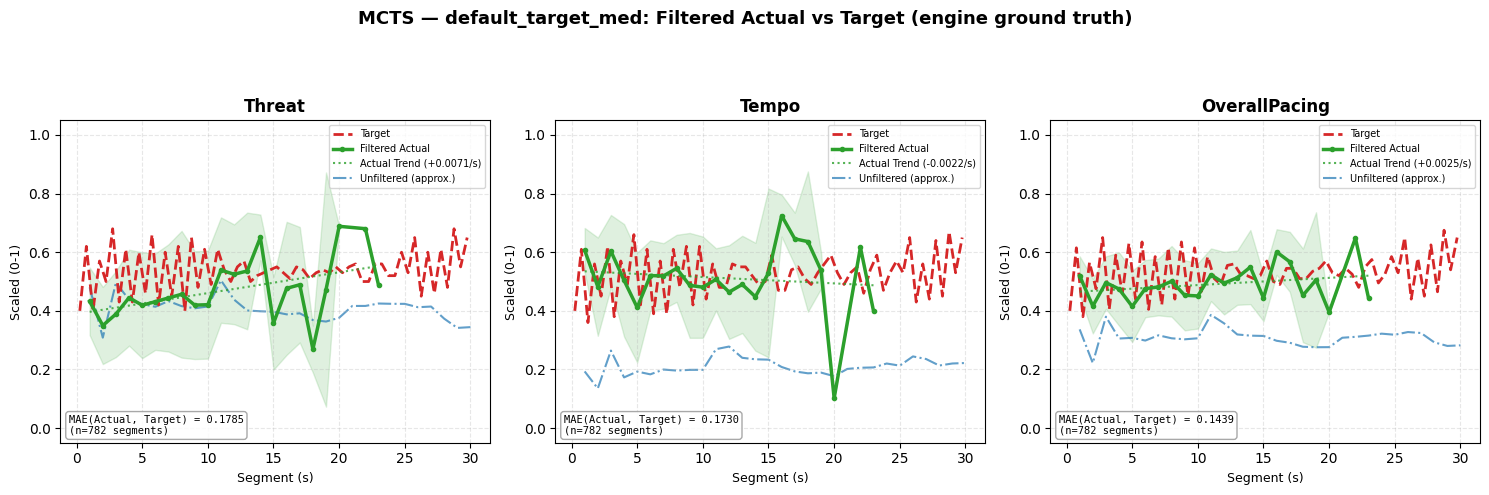

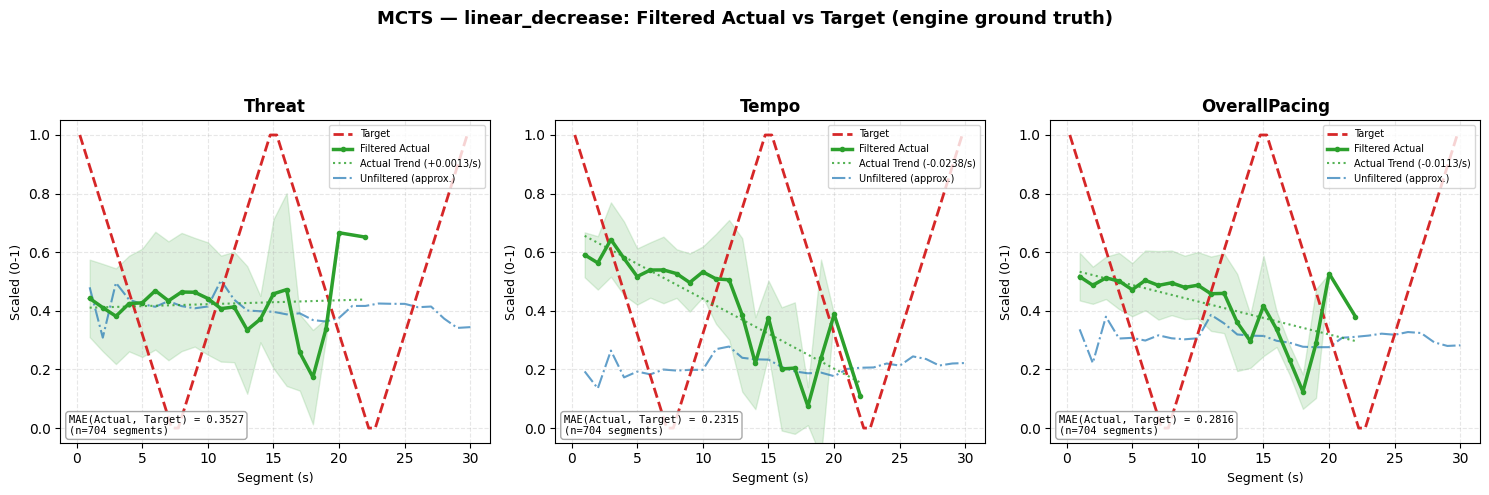

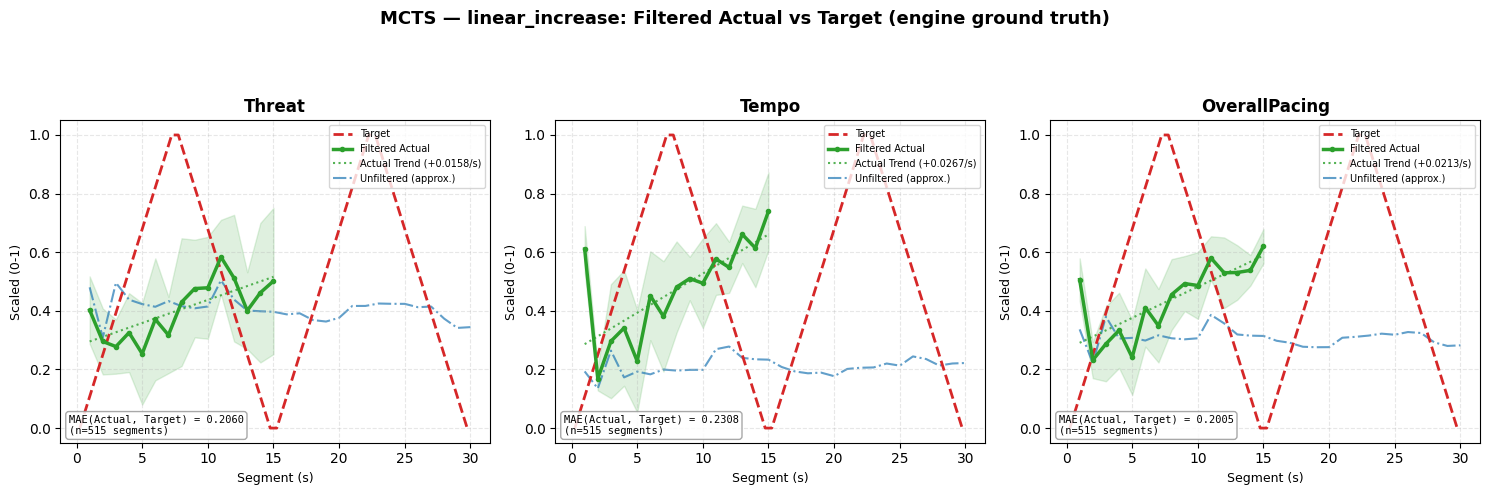

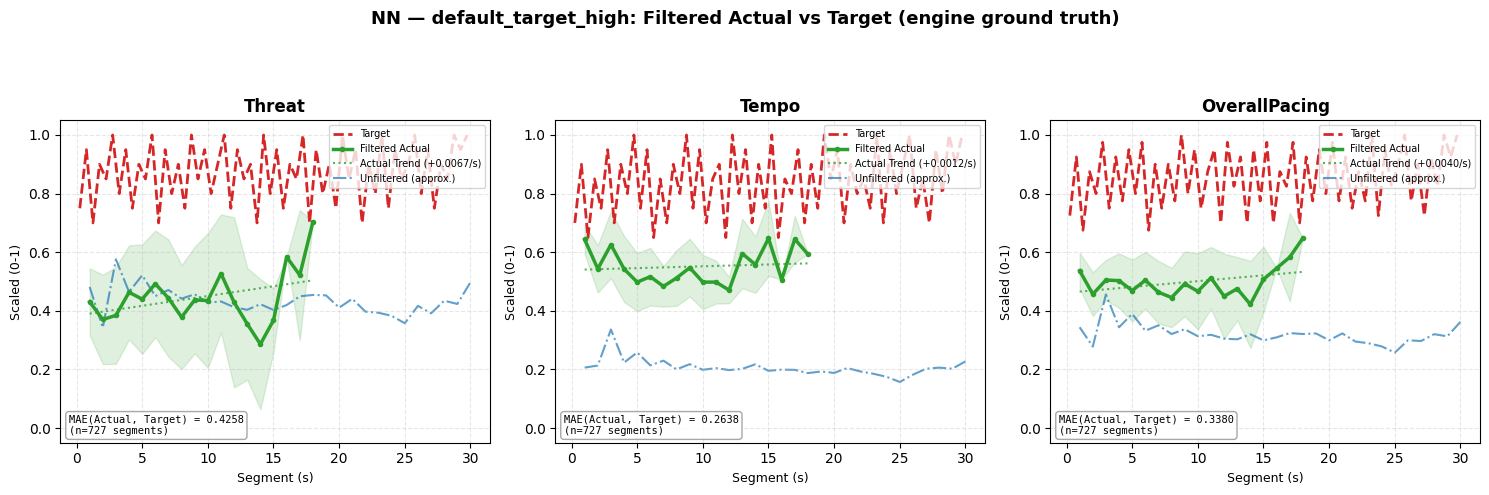

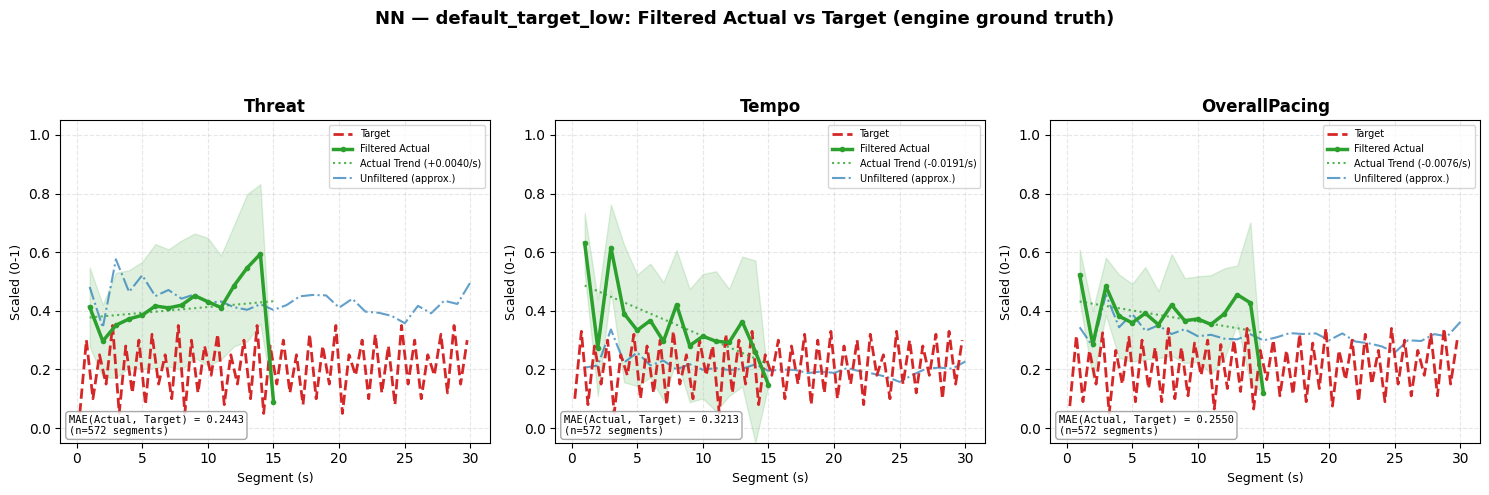

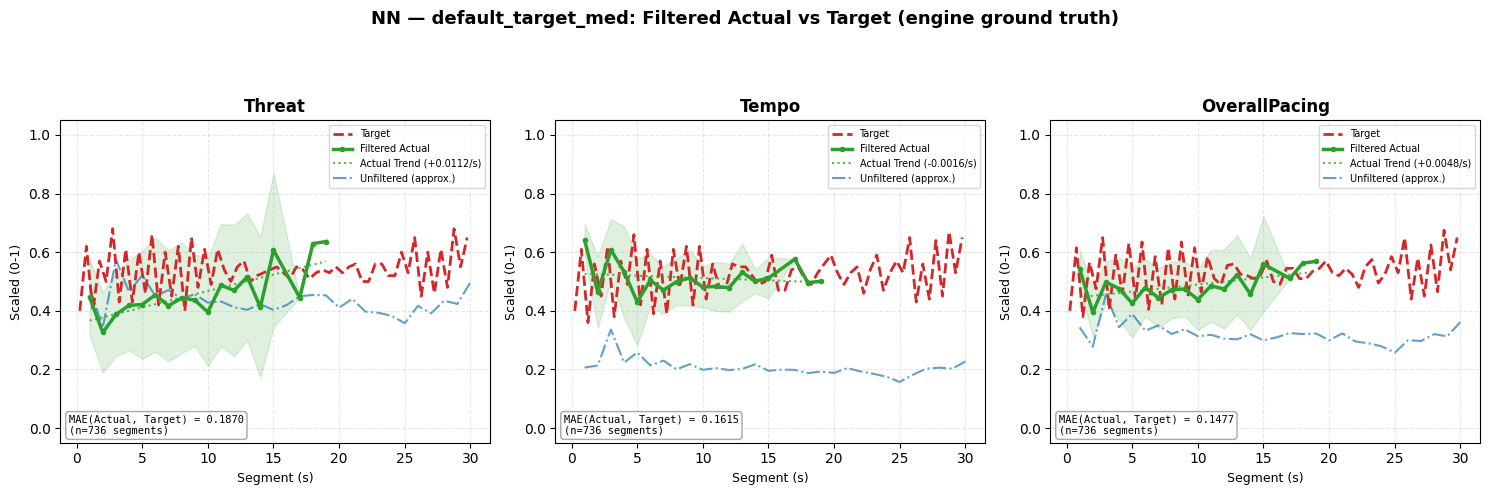

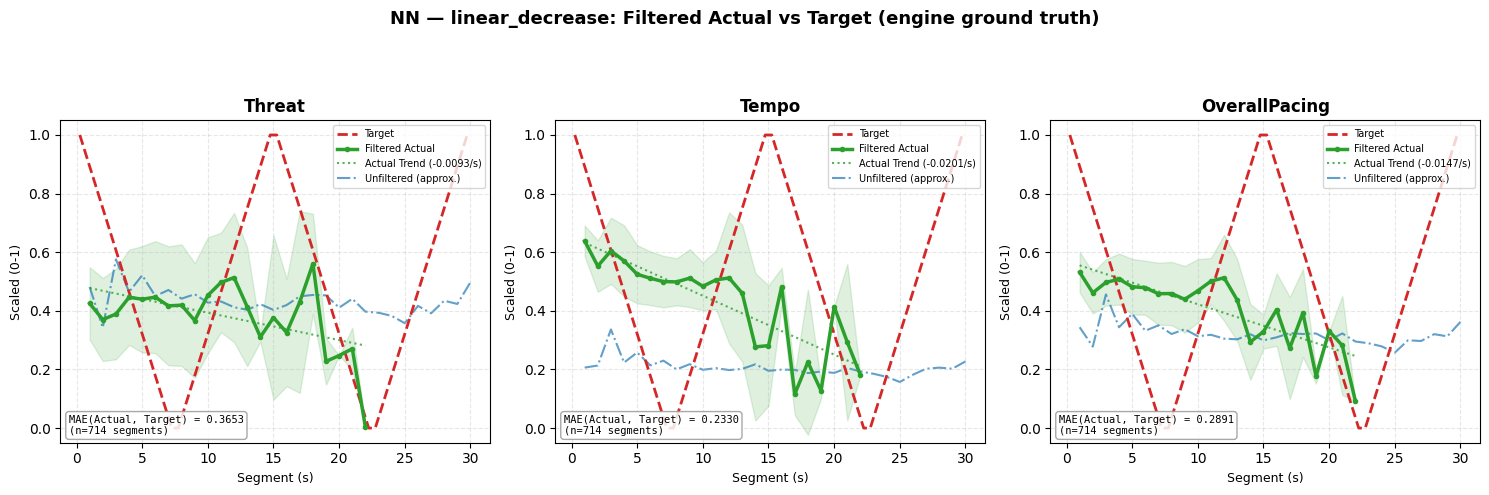

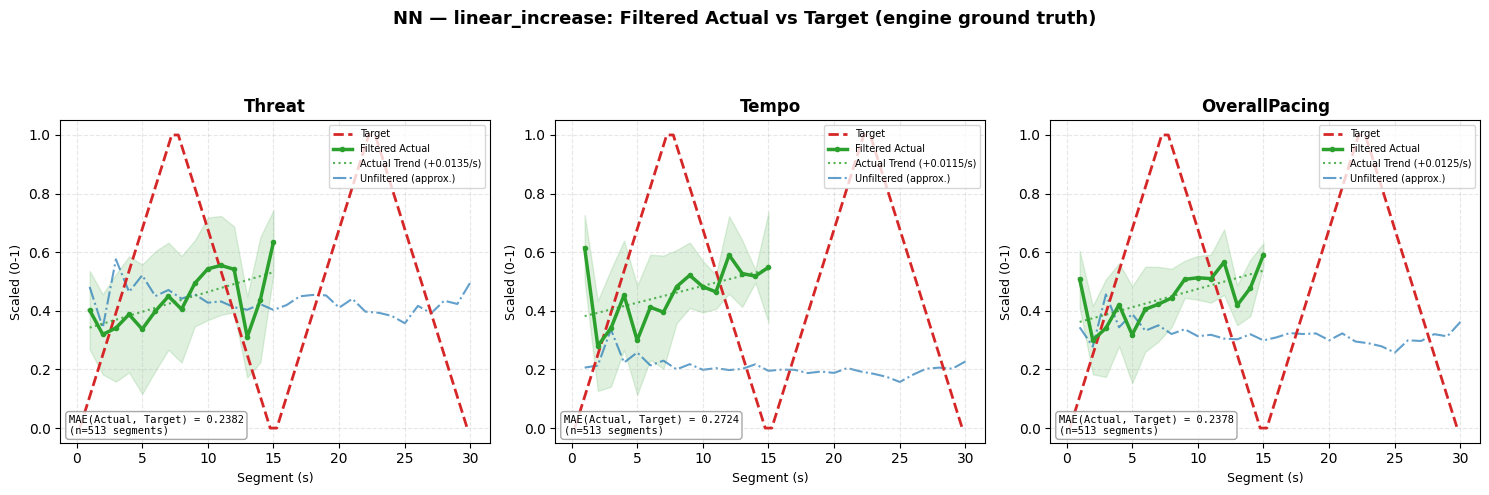

In [6]:
from plotting.pacing_filter_comparison import plot_all_filtered_target_tracking

figs_target_tracking = plot_all_filtered_target_tracking(
    df_pacing_factor_comparison, df_target_tracking, output_dir=comparison_output_dir,
    sim_targets_dir=sim_targets_dir,
)


### Merged (Both Applied Bots Pooled)

Same Actual-vs-Target tracking, but MCTS and NN pooled into one line per `PacingTarget` instead of a separate chart each — 5 figures total instead of 10. Mirrors how `plotting.pacing_target_analyzer.plot_pacing_target_tracking` already pools every "Applied"-role bot together by default.


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_default_target_high_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_default_target_low_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_default_target_med_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_linear_decrease_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_linear_increase_target_tracking.png


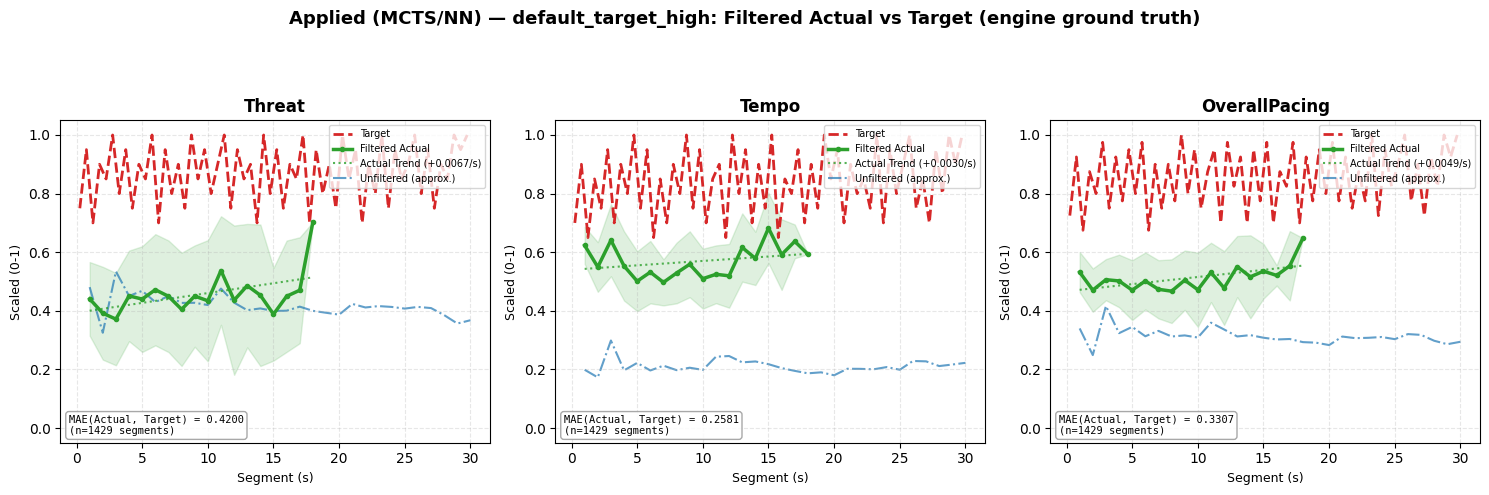

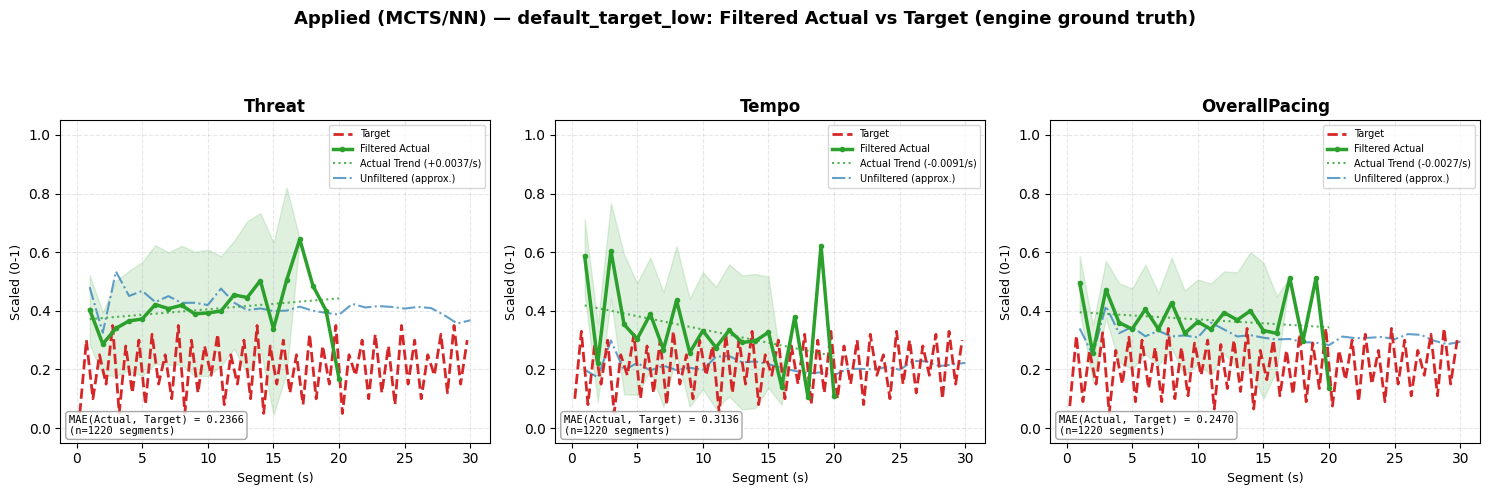

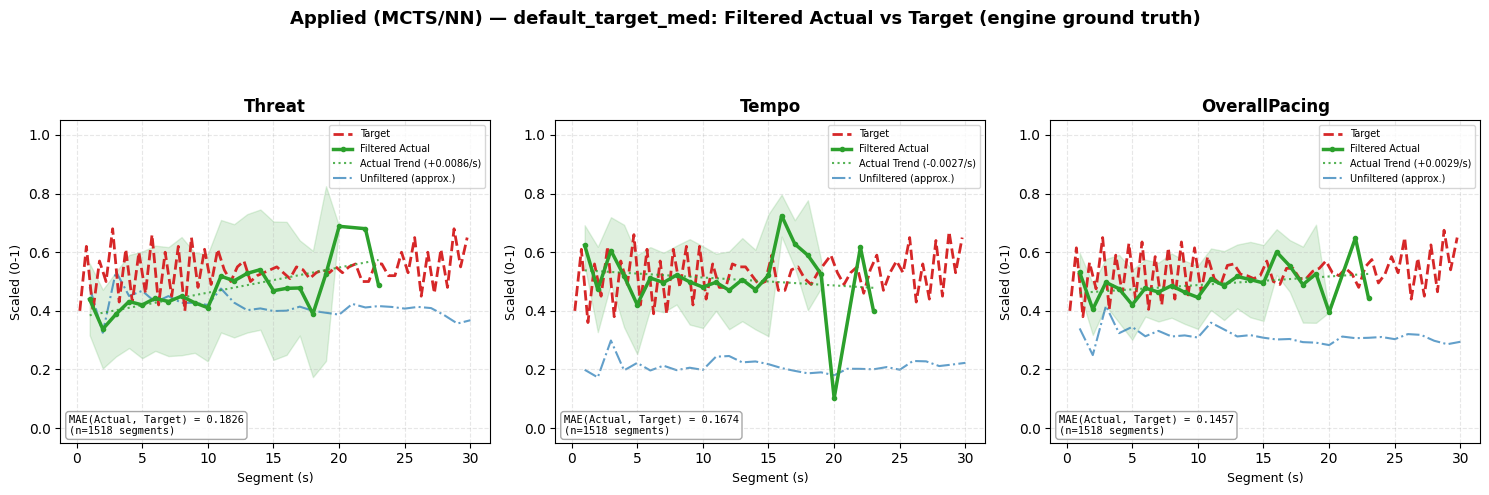

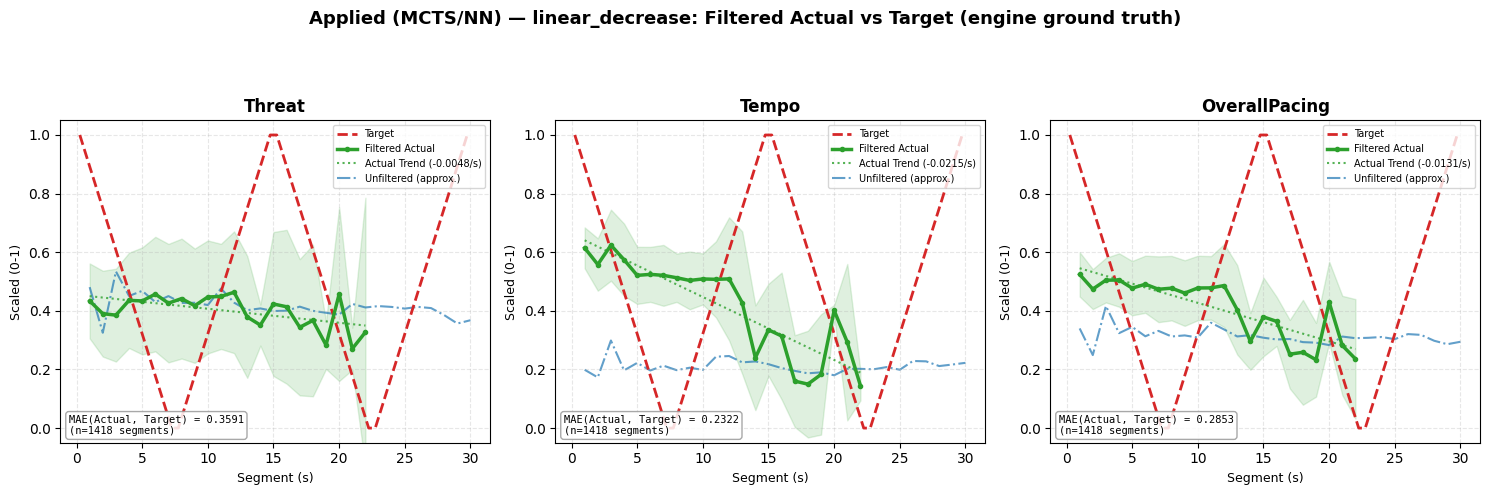

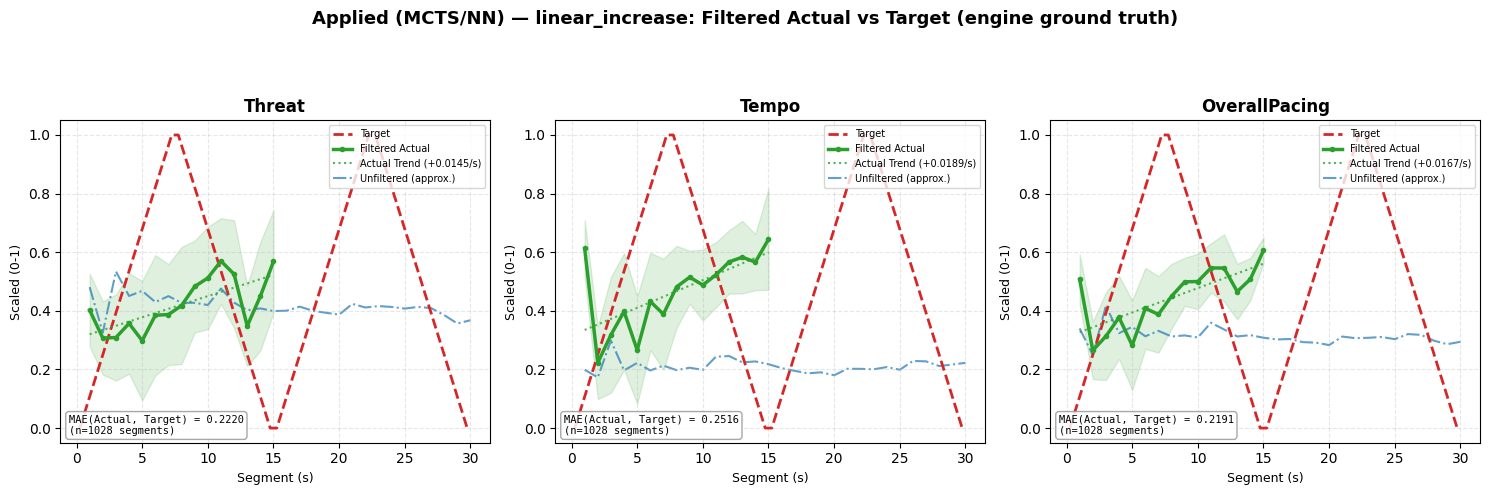

In [7]:
from plotting.pacing_filter_comparison import plot_all_filtered_target_tracking_merged

figs_target_tracking_merged = plot_all_filtered_target_tracking_merged(
    df_pacing_factor_comparison, df_target_tracking, output_dir=comparison_output_dir,
    sim_targets_dir=sim_targets_dir,
)


### Per-Bot (Not Pooled)

Same Actual-vs-Target tracking, but each applied bot (MCTS/NN) gets its own Filtered/Unfiltered/Trend lines instead of being averaged into one line - does each bot track the curve differently, rather than one pooled answer. `include_target`/`include_unfiltered`/`include_trend` toggle each line type off across every figure.


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/by_bot_default_target_high_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/by_bot_default_target_low_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/by_bot_default_target_med_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/by_bot_linear_decrease_target_tracking.png
✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/by_bot_linear_increase_target_tracking.png


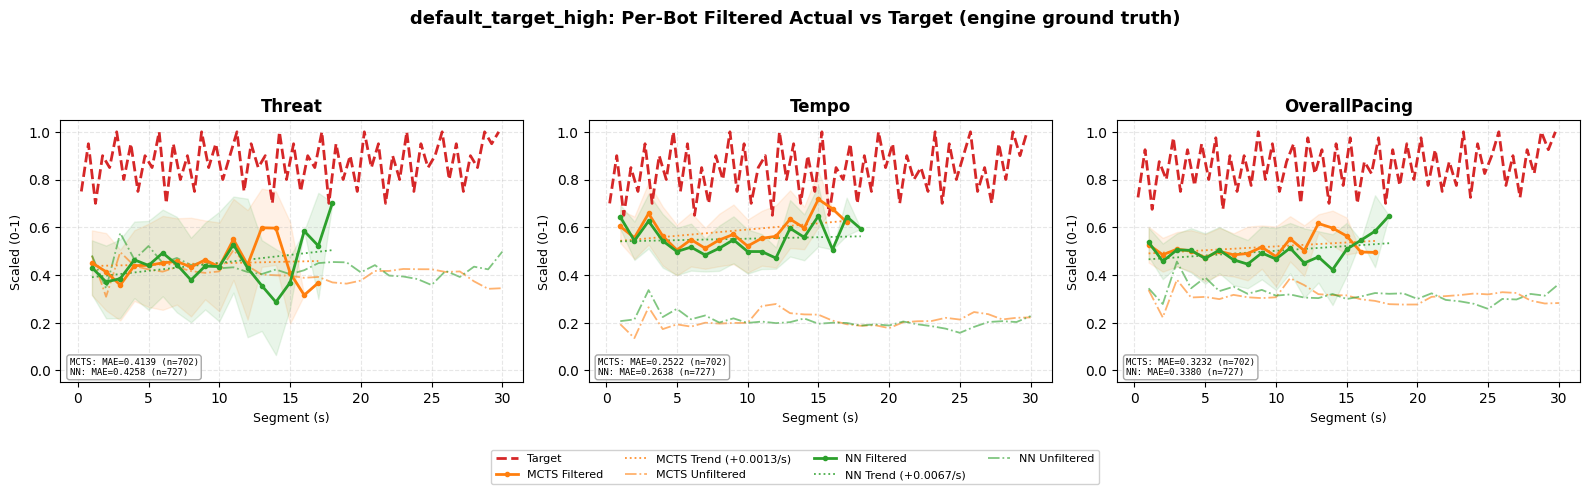

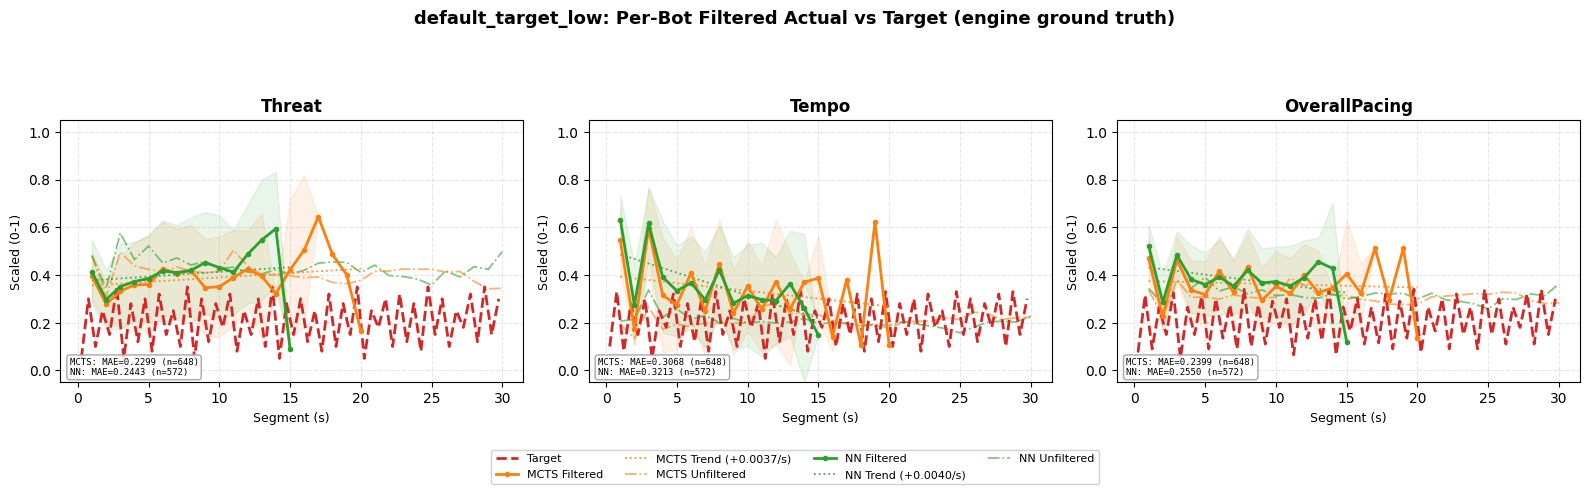

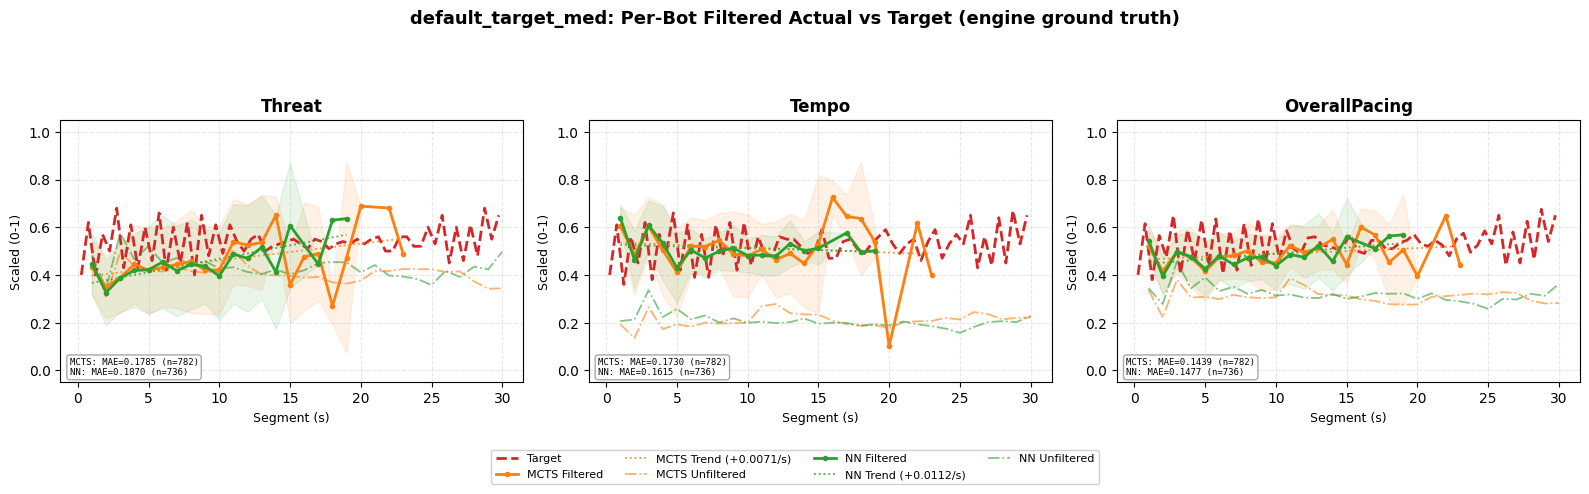

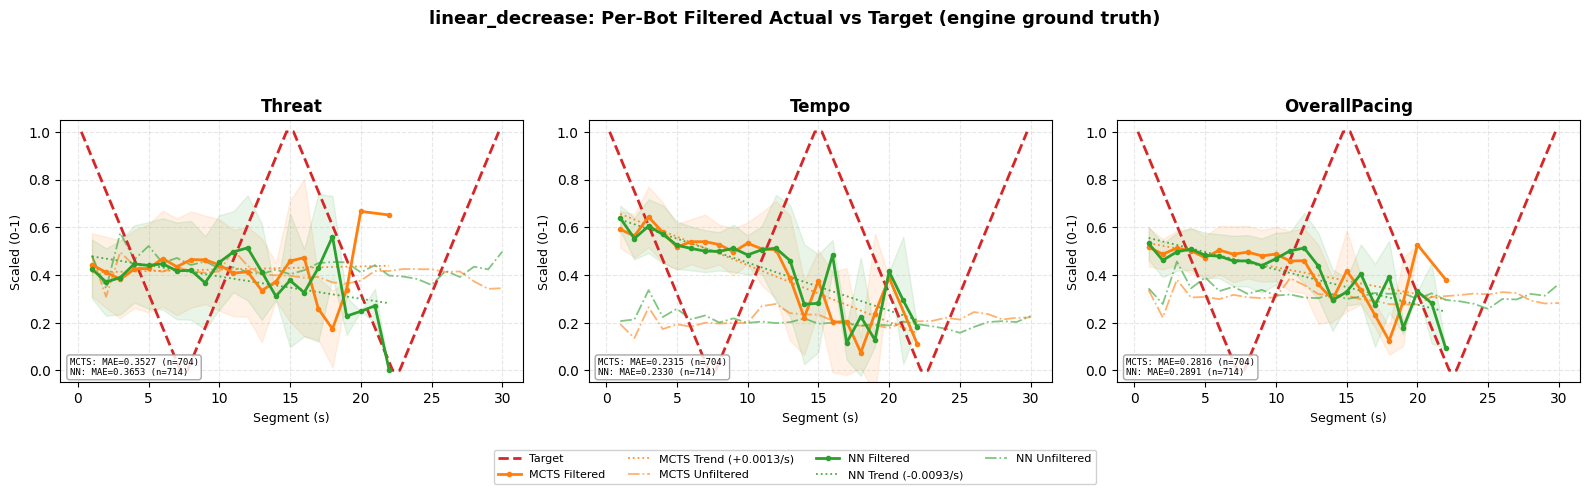

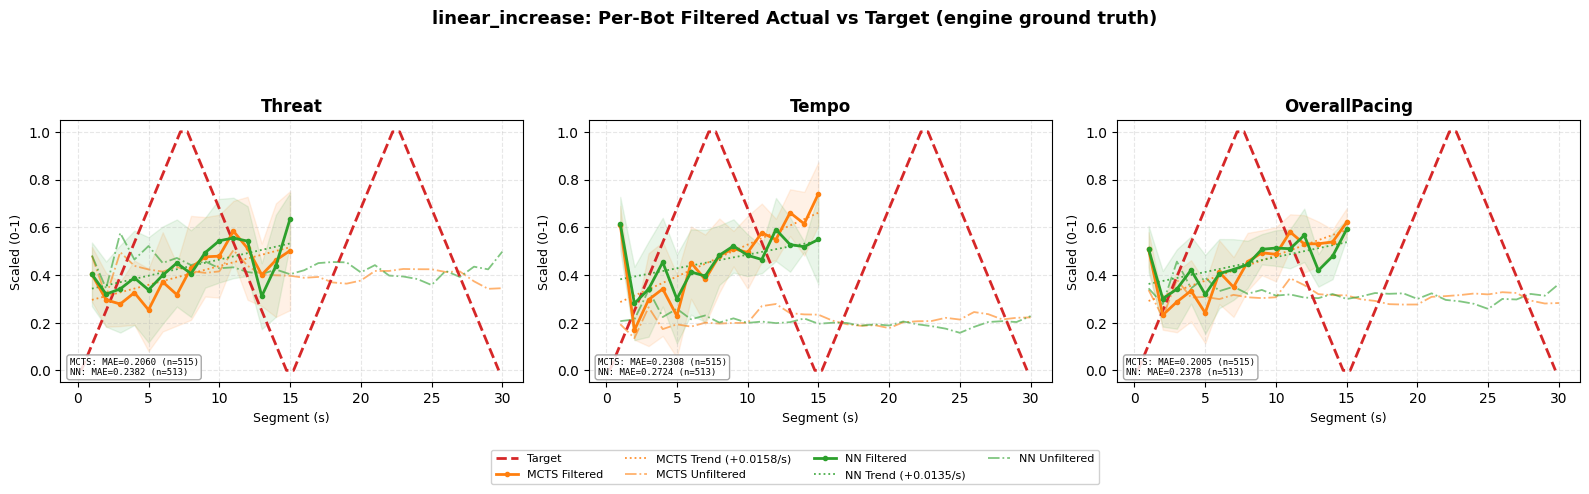

In [8]:
from plotting.pacing_filter_comparison import plot_all_filtered_target_tracking_by_bot

figs_target_tracking_by_bot = plot_all_filtered_target_tracking_by_bot(
    df_pacing_factor_comparison, df_target_tracking, output_dir=comparison_output_dir,
    sim_targets_dir=sim_targets_dir,
    include_target=True, include_unfiltered=True, include_trend=True,
)


### Tracking Error vs Target Curve Shape (Bot x Curve Archetype)

Instead of treating each `PacingTarget` config as an identity to name/render (doesn't scale past a handful of configs), both charts below derive shape features straight from the deterministic curve itself (`compute_target_curve_features`: Volatility, Amplitude, Trend, DirectionChanges) and plot/bucket by those instead:

- **Scatter**: x = target curve Volatility, y = tracking MAE, one point per (Bot, PacingTarget), colored by Bot, with a linear trend line - does tracking error actually scale with how erratic the target curve is? No PacingTarget name is ever drawn, so this scales to any number of configs.
- **Heatmap**: each `PacingTarget` is auto-bucketed into a curve Archetype (`Flat` / `Rising` / `Falling` / `Oscillating-Slow` / `Oscillating-Fast`, from the curve's own amplitude/trend/direction-change stats), then Bot x Archetype mean MAE is shown - a small, fixed-size grid regardless of how many raw target files exist.


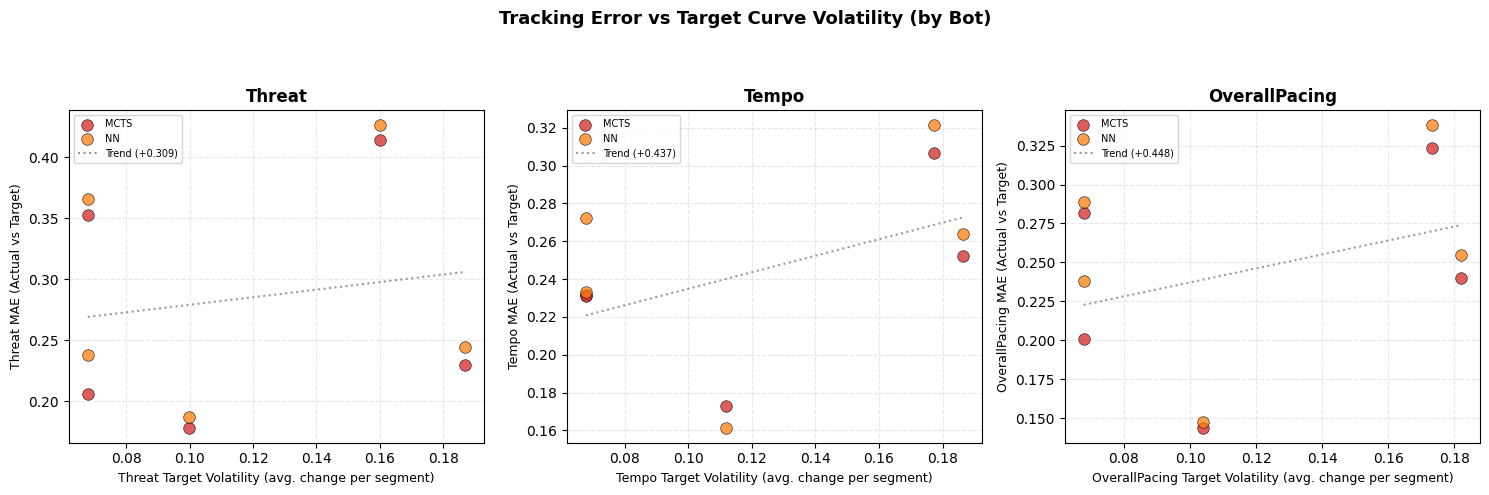

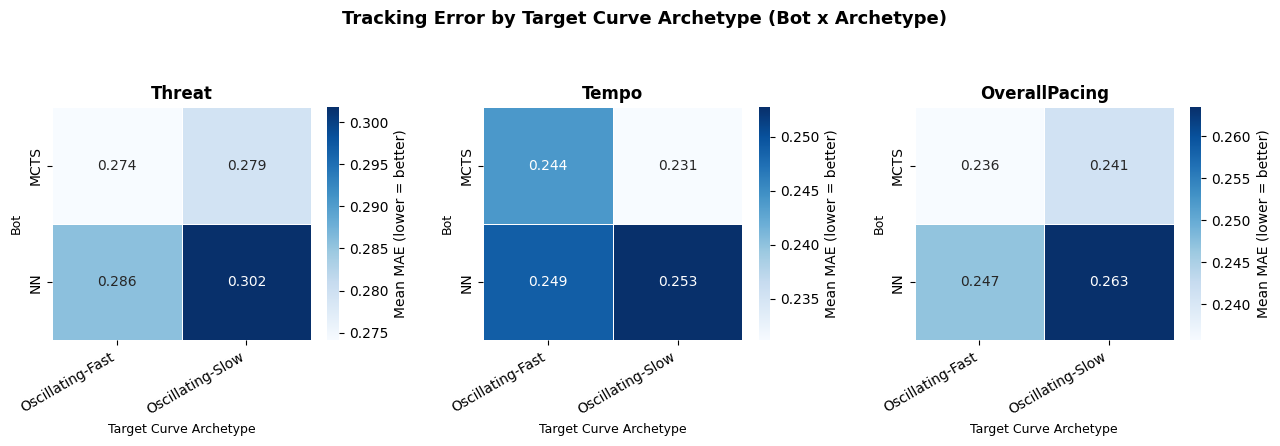

In [5]:
from plotting.pacing_filter_comparison import (
    plot_target_tracking_error_vs_volatility,
    plot_target_tracking_error_by_archetype_heatmap,
)

fig_error_vs_volatility = plot_target_tracking_error_vs_volatility(df_target_tracking, sim_targets_dir)
fig_error_by_archetype = plot_target_tracking_error_by_archetype_heatmap(df_target_tracking, sim_targets_dir)


### Tracking Error vs Win Rate

Does tracking the target curve more closely (lower MAE) actually correlate with winning more? Bins every applied bot's individual game by its MAE (see `compute_game_level_tracking_error` - one row per real game, keyed by `(Bot, PacingTarget, ConfigFolder, GameIndex)` since `GameIndex` alone only numbers games *within* one `ConfigFolder`) into quantiles and plots each bin's win rate, with the point-biserial correlation `r` annotated per panel.

> Needs `df_target_tracking` to include `ConfigFolder`/`GameIndex`/`Won` - re-run the "Prepare Data" cell above (`load_filtered_target_tracking`) if it was loaded before this was added.


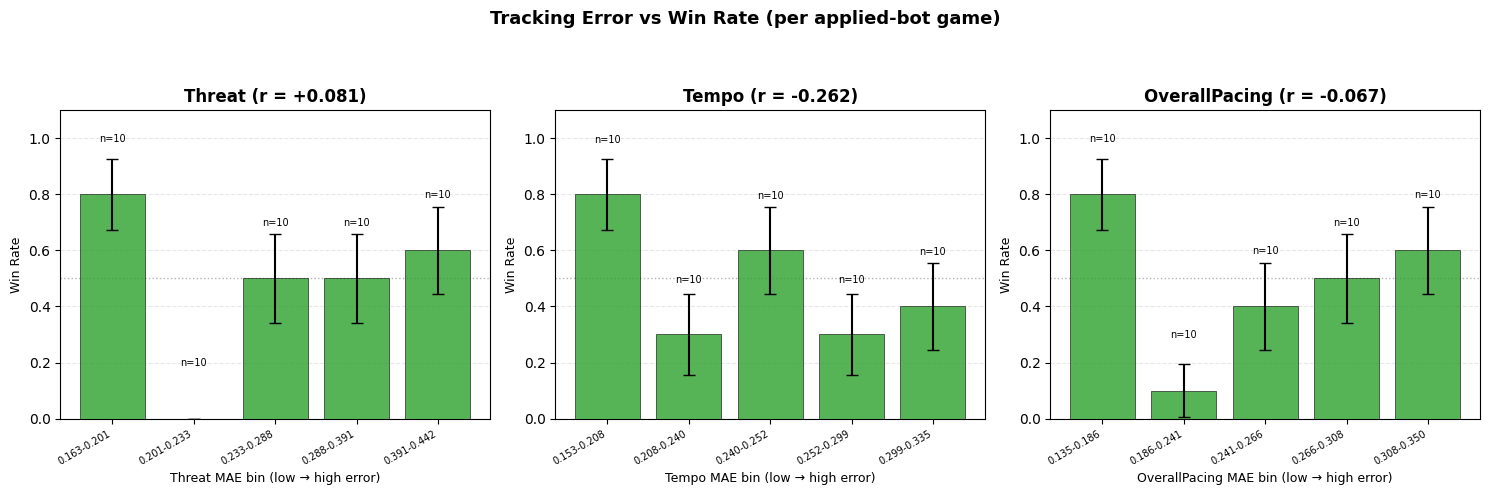

In [4]:
from plotting.pacing_filter_comparison import plot_tracking_error_vs_winrate

fig_error_vs_winrate = plot_tracking_error_vs_winrate(df_target_tracking, n_bins=5)
